# 🏥 CT Pathology Detection - Quick Start Guide

Этот ноутбук демонстрирует базовое использование системы для выявления патологий на КТ снимках.

**Что вы узнаете:**
- Инициализация pipeline
- Обработка ZIP архивов с DICOM/NIfTI
- Анализ результатов
- Визуализация статистики

**Требования:**
- Запущен install.sh
- Модели скачаны в папку models/
- Есть тестовые данные в формате ZIP

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Добавляем путь к проекту
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

from src.pipeline.core_pipeline import CTPathologyPipeline
from src.pipeline.data_models import PipelineConfig

print("✅ Импорты загружены")

✅ Импорты загружены


In [2]:
# =============================================================================
# = КОНФИГУРАЦИЯ СИСТЕМЫ  =
# =============================================================================
# Конфигурация pipeline
config = PipelineConfig(
    ct_clip_checkpoint="models/CT_LiPro_v2.pt",
    catboost_model="models/catboost_pathology_classifier.cbm",
    text_prompt="chest computed tomography scan for pathology detection",
    device="cpu",  # Измените на "cpu" если нет GPU
    max_workers=1,  # Количество параллельных потоков
    log_level="INFO"
)

print("✅ Конфигурация создана")
print(f"   Модель CT-CLIP: {config.ct_clip_checkpoint}")
print(f"   Модель CatBoost: {config.catboost_model}")
print(f"   Устройство: {config.device}")

✅ Конфигурация создана
   Модель CT-CLIP: models/CT_LiPro_v2.pt
   Модель CatBoost: models/catboost_pathology_classifier.cbm
   Устройство: cpu


In [3]:
# =============================================================================
# == ИНИЦИАЛИЗАЦИЯ PIPELINE == 
# =============================================================================
print("⏳ Инициализация pipeline (может занять 1-2 минуты)...")

pipeline = CTPathologyPipeline(config)

print("✅ Pipeline успешно инициализирован!")
print("   CT-CLIP модель загружена")
print("   CatBoost классификатор загружен")

2025-10-18 23:10:20,987 - src.pipeline.core_pipeline - INFO - Initializing models...


⏳ Инициализация pipeline (может занять 1-2 минуты)...


/Users/ilaskvorcov/Desktop/дело/chest-ct-classification/ct_hackathon_env/lib/python3.11/site-packages/vector_quantize_pytorch/vector_quantize_pytorch.py:261: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
/Users/ilaskvorcov/Desktop/дело/chest-ct-classification/ct_hackathon_env/lib/python3.11/site-packages/vector_quantize_pytorch/vector_quantize_pytorch.py:391: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
Unexpected keys in checkpoint: 1
2025-10-18 23:10:27,759 - src.pipeline.core_pipeline - INFO - CT-CLIP model loaded successfully
2025-10-18 23:10:27,802 - src.pipeline.core_pipeline - INFO - CatBoost model loaded successfully


✅ Pipeline успешно инициализирован!
   CT-CLIP модель загружена
   CatBoost классификатор загружен


In [5]:
# ВАЖНО: Укажите пути к вашим ZIP архивам с DICOM или NIfTI файлами
# Пример структуры ZIP:
#   study.zip
#   ├── series1/
#   │   ├── 001.dcm
#   │   ├── 002.dcm
#   │   └── ...
#   └── series2/
#       ├── 001.dcm
#       └── ...

# Укажите пути к вашим данным
zip_paths = [
    #"data/Датасет/norma_anon.zip",
    #"data/Датасет/pneumonia_anon.zip",
    "data/Датасет/combined TEST CT.zip"
]

existing_zips = [p for p in zip_paths if Path(p).exists()]

if len(existing_zips) == 0:
    print("⚠️  ВНИМАНИЕ: Не найдены ZIP файлы!")
    print("   Укажите корректные пути в переменной zip_paths")
else:
    print(f"✅ Найдено {len(existing_zips)} ZIP архивов для обработки:")
    for zip_path in existing_zips:
        size_mb = Path(zip_path).stat().st_size / (1024**2)
        print(f"   - {zip_path} ({size_mb:.1f} MB)")

✅ Найдено 1 ZIP архивов для обработки:
   - data/Датасет/combined TEST CT.zip (1879.3 MB)


In [13]:
import os
import sys
import traceback
import logging
from pathlib import Path
import pydicom
import pandas as pd

# === ЛОГИРОВАНИЕ ===
logger = logging.getLogger("dicom_uid_probe")
logger.handlers.clear()
handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(logging.Formatter("%(levelname)s | %(message)s"))
logger.addHandler(handler)
logger.setLevel(logging.DEBUG)

base_dir = Path("data/Датасет")  # при необходимости поменяйте путь
logger.debug(f"Base dir: {base_dir} | exists={base_dir.exists()} | is_dir={base_dir.is_dir()}")

def find_first_dicom(ds_dir: Path):
    # Рекурсивно ищем первый читаемый DICOM
    files_checked = 0
    for fp in sorted(ds_dir.rglob("*")):
        if not fp.is_file():
            continue
        files_checked += 1
        # Быстрый фильтр по расширению (может быть без .dcm — оставляем эвристику)
        if fp.suffix.lower() not in {".dcm", "" , ".DCM"}:
            # всё равно пытаемся читать, но можно ускорить, фильтруя по сигнатурам
            pass
        try:
            logger.debug(f"Try read DICOM (stop_before_pixels) :: {fp}")
            ds = pydicom.dcmread(str(fp), stop_before_pixels=True, force=False)
            logger.debug(f"Read OK (force=False) :: {fp}")
            return ds, fp, files_checked, None
        except Exception as e1:
            err1 = f"{type(e1).__name__}: {e1}"
            logger.debug(f"Read failed (force=False) :: {fp} :: {err1}")
            try:
                logger.debug(f"Try read DICOM with force=True :: {fp}")
                ds = pydicom.dcmread(str(fp), stop_before_pixels=True, force=True)
                logger.debug(f"Read OK (force=True) :: {fp}")
                return ds, fp, files_checked, None
            except Exception as e2:
                err2 = f"{type(e2).__name__}: {e2}"
                logger.debug(f"Read failed (force=True) :: {fp} :: {err2}")
                continue
    return None, None, files_checked, "no_readable_dicom"

rows = []
if not base_dir.exists() or not base_dir.is_dir():
    logger.error("Base directory not found or not a directory")
else:
    subdirs = sorted([p for p in base_dir.iterdir() if p.is_dir()])
    logger.debug(f"Found {len(subdirs)} subdirs under base_dir")
    for study_dir in subdirs:
        logger.debug(f"Inspect dir: {study_dir}")
        # Подсчёт файлов (плоско и рекурсивно)
        flat_files = [f for f in study_dir.iterdir() if f.is_file()]
        deep_files = [f for f in study_dir.rglob("*") if f.is_file()]
        logger.debug(f"Files (flat)={len(flat_files)} | Files (recursive)={len(deep_files)}")
        try:
            ds, fp, checked, err = find_first_dicom(study_dir)
            if ds is None:
                status = f"Failure: {err} | checked_files={checked}"
                logger.warning(f"{study_dir.name} :: {status}")
                rows.append({
                    "folder": study_dir.name,
                    "first_file": None,
                    "checked_files": checked,
                    "study_uid_(0020,000D)": None,
                    "series_uid_(0020,000E)": None,
                    "status": status
                })
                continue
            study_uid = getattr(ds, "StudyInstanceUID", None)
            series_uid = getattr(ds, "SeriesInstanceUID", None)
            status = "Success" if (study_uid and series_uid) else "Failure: missing UID"
            logger.info(f"{study_dir.name} :: file={fp.name} :: StudyUID={study_uid} :: SeriesUID={series_uid} :: {status}")
            rows.append({
                "folder": study_dir.name,
                "first_file": str(fp.relative_to(study_dir)) if fp else None,
                "checked_files": checked,
                "study_uid_(0020,000D)": str(study_uid) if study_uid else None,
                "series_uid_(0020,000E)": str(series_uid) if series_uid else None,
                "status": status
            })
        except Exception as e:
            tb = traceback.format_exc(limit=2)
            logger.error(f"Unexpected error in {study_dir.name}: {e}")
            rows.append({
                "folder": study_dir.name,
                "first_file": None,
                "checked_files": 0,
                "study_uid_(0020,000D)": None,
                "series_uid_(0020,000E)": None,
                "status": f"Failure: exception :: {type(e).__name__}: {e} :: {tb}"
            })

df = pd.DataFrame(rows)
print("\n=== RESULT TABLE ===")
print(df.to_string(index=False))

# По желанию: сохранить в CSV для дальнейшего анализа
# df.to_csv("norma_anon_uids_probe.csv", index=False)


DEBUG | Base dir: data/Датасет | exists=True | is_dir=True
DEBUG | Found 3 subdirs under base_dir
DEBUG | Inspect dir: data/Датасет/norma_anon
DEBUG | Files (flat)=451 | Files (recursive)=451
DEBUG | Try read DICOM (stop_before_pixels) :: data/Датасет/norma_anon/10000E6B_anon
DEBUG | Read OK (force=False) :: data/Датасет/norma_anon/10000E6B_anon
INFO | norma_anon :: file=10000E6B_anon :: StudyUID=1.2.276.0.7230010.3.1.2.2462171185.19116.1754559949.863 :: SeriesUID=1.2.276.0.7230010.3.1.3.2462171185.19116.1754559949.864 :: Success
DEBUG | Inspect dir: data/Датасет/pneumonia_anon
DEBUG | Files (flat)=367 | Files (recursive)=367
DEBUG | Try read DICOM (stop_before_pixels) :: data/Датасет/pneumonia_anon/1000032A_anon
DEBUG | Read OK (force=False) :: data/Датасет/pneumonia_anon/1000032A_anon
INFO | pneumonia_anon :: file=1000032A_anon :: StudyUID=1.2.276.0.7230010.3.1.2.2462171185.19116.1754559747.125 :: SeriesUID=1.2.276.0.7230010.3.1.3.2462171185.19116.1754559747.126 :: Success
DEBUG | In

In [9]:
from pathlib import Path

dir = Path("data/Датасет/norma_anon")

for file in dir.iterdir():
    print(file)

data/Датасет/norma_anon/10000FEC_anon
data/Датасет/norma_anon/10000E97_anon
data/Датасет/norma_anon/10000E78_anon
data/Датасет/norma_anon/10000F51_anon
data/Датасет/norma_anon/10000E7C_anon
data/Датасет/norma_anon/10000FE8_anon
data/Датасет/norma_anon/1000101A_anon
data/Датасет/norma_anon/10000EB6_anon
data/Датасет/norma_anon/10000F06_anon
data/Датасет/norma_anon/10000FAB_anon
data/Датасет/norma_anon/10000EC0_anon
data/Датасет/norma_anon/10000F10_anon
data/Датасет/norma_anon/10000FA9_anon
data/Датасет/norma_anon/10000EF7_anon
data/Датасет/norma_anon/10000E81_anon
data/Датасет/norma_anon/10000FDE_anon
data/Датасет/norma_anon/10000E6E_anon
data/Датасет/norma_anon/10000F47_anon
data/Датасет/norma_anon/10000FC5_anon
data/Датасет/norma_anon/10001020_anon
data/Датасет/norma_anon/10000FF2_anon
data/Датасет/norma_anon/10000F84_anon
data/Датасет/norma_anon/10000F7F_anon
data/Датасет/norma_anon/10000F92_anon
data/Датасет/norma_anon/10000EEF_anon
data/Датасет/norma_anon/10000F2A_anon
data/Датасет

In [6]:
# =============================================================================
#  ОБРАБОТКА ДАННЫХ
# =============================================================================
if len(existing_zips) > 0:
    print("\n⏳ Начинаем обработку...")
    print(f"   Архивов для обработки: {len(existing_zips)}")
    
    # Обработка через pipeline
    results = pipeline.process_zip_archives(
        zip_paths=existing_zips,
        output_excel="quick_start_results.xlsx"
    )
    
    print("\n✅ ОБРАБОТКА ЗАВЕРШЕНА!")
    print(f"   📊 Обработано исследований: {len(results)}")
    print(f"   📁 Результаты сохранены: quick_start_results.xlsx")
else:
    print("❌ Нет данных для обработки. Добавьте ZIP файлы.")

2025-10-18 23:11:51,816 - src.pipeline.core_pipeline - INFO - Processing 1 ZIP archives
2025-10-18 23:11:51,817 - src.pipeline.core_pipeline - INFO - Processing ZIP: data/Датасет/combined TEST CT.zip
2025-10-18 23:11:51,821 - src.pipeline.core_pipeline - INFO - Discovering studies in data/Датасет/combined TEST CT.zip



⏳ Начинаем обработку...
   Архивов для обработки: 1


2025-10-18 23:12:01,383 - src.pipeline.core_pipeline - INFO - Found NIfTI: study_0002.nii.gz
2025-10-18 23:12:01,390 - src.pipeline.core_pipeline - INFO - Found NIfTI: study_0266.nii.gz
2025-10-18 23:12:01,391 - src.pipeline.core_pipeline - INFO - Found NIfTI: study_0285.nii.gz
2025-10-18 23:12:01,391 - src.pipeline.core_pipeline - INFO - Found NIfTI: study_0004.nii.gz
2025-10-18 23:12:01,391 - src.pipeline.core_pipeline - INFO - Found NIfTI: study_0261.nii.gz
2025-10-18 23:12:01,391 - src.pipeline.core_pipeline - INFO - Found NIfTI: study_0280.nii.gz
2025-10-18 23:12:01,392 - src.pipeline.core_pipeline - INFO - Found NIfTI: study_0001.nii.gz
2025-10-18 23:12:01,392 - src.pipeline.core_pipeline - INFO - Found NIfTI: study_0282.nii.gz
2025-10-18 23:12:01,392 - src.pipeline.core_pipeline - INFO - Found NIfTI: study_0003.nii.gz
2025-10-18 23:12:01,392 - src.pipeline.core_pipeline - INFO - Found NIfTI: study_0005.nii.gz
2025-10-18 23:12:01,809 - src.pipeline.core_pipeline - INFO - Found DI


✅ ОБРАБОТКА ЗАВЕРШЕНА!
   📊 Обработано исследований: 25
   📁 Результаты сохранены: quick_start_results.xlsx


In [10]:
df = pd.read_excel("quick_start_results.xlsx", sheet_name="Results")
df.path_to_study.to_list()

['/var/folders/qx/1rcjjd5n01xcxrjkz1rlv4tr0000gn/T/ct_pathology__qkmclrg/norma_anon',
 '/var/folders/qx/1rcjjd5n01xcxrjkz1rlv4tr0000gn/T/ct_pathology_pkmud3qp/pneumonia_anon']

In [6]:
# =============================================================================
# АНАЛИЗ РЕЗУЛЬТАТОВ
# =============================================================================
if len(existing_zips) > 0:
    # Загрузка результатов
    df = pd.read_excel("quick_start_results.xlsx", sheet_name="Results")
    
    # Базовая статистика
    success_count = (df['processing_status'] == 'Success').sum()
    failed_count = (df['processing_status'] == 'Failure').sum()
    pathology_count = (df['pathology'] == 1).sum()
    normal_count = (df['pathology'] == 0).sum()
    
    print("\n" + "="*60)
    print("📊 СТАТИСТИКА ОБРАБОТКИ")
    print("="*60)
    print(f"✅ Успешно обработано: {success_count}/{len(df)}")
    print(f"❌ Ошибок обработки: {failed_count}/{len(df)}")
    print(f"\n🔬 РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:")
    print(f"🔴 Патологий обнаружено: {pathology_count} ({pathology_count/len(df)*100:.1f}%)")
    print(f"🟢 Норма: {normal_count} ({normal_count/len(df)*100:.1f}%)")
    print(f"\n📈 Средняя вероятность патологии: {df['probability_of_pathology'].mean():.4f}")
    print(f"📉 Медиана: {df['probability_of_pathology'].median():.4f}")
    print("="*60)
    
    # Показываем первые результаты
    print("\n📋 Первые 5 результатов:")
    display(df[['study_uid', 'series_uid', 'probability_of_pathology', 'pathology', 'processing_status']].head())


📊 СТАТИСТИКА ОБРАБОТКИ
✅ Успешно обработано: 0/2
❌ Ошибок обработки: 2/2

🔬 РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:
🔴 Патологий обнаружено: 0 (0.0%)
🟢 Норма: 2 (100.0%)

📈 Средняя вероятность патологии: 0.0000
📉 Медиана: 0.0000

📋 Первые 5 результатов:


,study_uid,series_uid,probability_of_pathology,pathology,processing_status
0,1.2.276.0.7230010.3.1.2.2462171185.19116.17545...,1.2.276.0.7230010.3.1.3.2462171185.19116.17545...,0,0,Failure
1,1.2.276.0.7230010.3.1.2.2462171185.19116.17545...,1.2.276.0.7230010.3.1.3.2462171185.19116.17545...,0,0,Failure


In [28]:
df.study_uid.nunique()

2

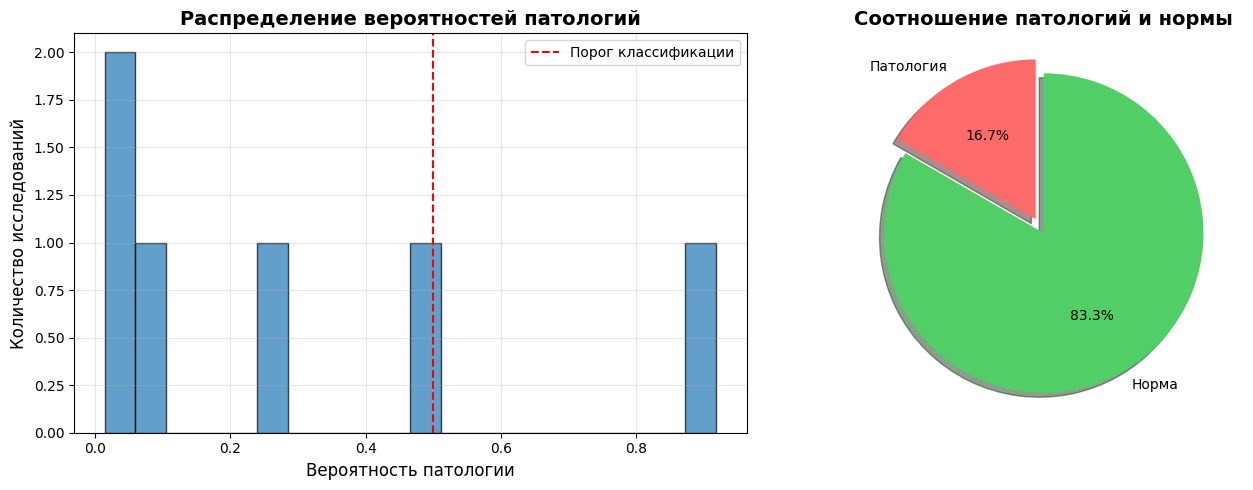

✅ Визуализация сохранена: quick_start_visualization.png


In [9]:
# =============================================================================
# ВИЗУАЛИЗАЦИЯ
# =============================================================================
if len(existing_zips) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График 1: Распределение вероятностей
    axes[0].hist(df['probability_of_pathology'], bins=20, edgecolor='black', alpha=0.7)
    axes[0].axvline(0.5, color='red', linestyle='--', label='Порог классификации')
    axes[0].set_xlabel('Вероятность патологии', fontsize=12)
    axes[0].set_ylabel('Количество исследований', fontsize=12)
    axes[0].set_title('Распределение вероятностей патологий', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # График 2: Pie chart результатов
    labels = ['Патология', 'Норма']
    sizes = [pathology_count, normal_count]
    colors = ['#ff6b6b', '#51cf66']
    explode = (0.1, 0)
    
    axes[1].pie(sizes, explode=explode, labels=labels, colors=colors,
                autopct='%1.1f%%', shadow=True, startangle=90)
    axes[1].set_title('Соотношение патологий и нормы', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('quick_start_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✅ Визуализация сохранена: quick_start_visualization.png")

In [10]:
# =============================================================================
# == ДЕТАЛЬНЫЙ АНАЛИЗ ПАТОЛОГИЙ
# =============================================================================
if len(existing_zips) > 0 and pathology_count > 0:
    print("\n" + "="*60)
    print("🔍 ДЕТАЛЬНЫЙ АНАЛИЗ ПАТОЛОГИЙ")
    print("="*60)
    
    # Фильтруем только патологии
    pathologies = df[df['pathology'] == 1].sort_values('probability_of_pathology', ascending=False)
    
    print(f"\n📌 Топ-5 исследований с наивысшей вероятностью патологии:")
    for idx, row in pathologies.head(5).iterrows():
        series_short = row['series_uid'][:40] + "..." if len(row['series_uid']) > 40 else row['series_uid']
        print(f"\n{idx+1}. Series: {series_short}")
        print(f"   Вероятность: {row['probability_of_pathology']:.4f} ({row['probability_of_pathology']*100:.2f}%)")
        print(f"   Статус: {row['processing_status']}")


🔍 ДЕТАЛЬНЫЙ АНАЛИЗ ПАТОЛОГИЙ

📌 Топ-5 исследований с наивысшей вероятностью патологии:

6. Series: 1.2.643.5.1.13.13.12.2.77.8252.050204150...
   Вероятность: 0.9175 (91.75%)
   Статус: Success


In [11]:
print("\n" + "="*60)
print("QUICK START ЗАВЕРШЁН!")
print("="*60)
print("\n Что было сделано:")
print("   1. Инициализирован pipeline с CT-CLIP и CatBoost")
print("   2. Обработаны ZIP архивы с медицинскими изображениями")
print("   3. Сгенерированы детальные результаты в Excel")
print("   4. Проведён анализ и визуализация данных")

print("\n📚 Следующие шаги:")
print("   - Изучите детальные результаты в quick_start_results.xlsx")
print("   - Проверьте лист 'Errors' для анализа ошибок")
print("   - Используйте лист 'Summary' для общей статистики")
print("   - Примените pipeline к вашим собственным данным")

print("\n📖 Дополнительная документация:")
print("   - notebooks/final.ipynb - полный эксперимент с обучением")
print("   - README.md - детальное описание системы")
print("   - src/pipeline/core_pipeline.py - API документация")

print("\n💡 Совет: Для обработки больших объёмов данных используйте:")
print("   - GPU для ускорения (device='cuda')")
print("   - Увеличьте max_workers для параллелизма")
print("   - Используйте batch обработку через glob")


QUICK START ЗАВЕРШЁН!

 Что было сделано:
   1. Инициализирован pipeline с CT-CLIP и CatBoost
   2. Обработаны ZIP архивы с медицинскими изображениями
   3. Сгенерированы детальные результаты в Excel
   4. Проведён анализ и визуализация данных

📚 Следующие шаги:
   - Изучите детальные результаты в quick_start_results.xlsx
   - Проверьте лист 'Errors' для анализа ошибок
   - Используйте лист 'Summary' для общей статистики
   - Примените pipeline к вашим собственным данным

📖 Дополнительная документация:
   - notebooks/final.ipynb - полный эксперимент с обучением
   - README.md - детальное описание системы
   - src/pipeline/core_pipeline.py - API документация

💡 Совет: Для обработки больших объёмов данных используйте:
   - GPU для ускорения (device='cuda')
   - Увеличьте max_workers для параллелизма
   - Используйте batch обработку через glob
